In [ ]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# TensorFlow Keras 라이브러리를 불러옵니다.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

1.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

2.

In [ ]:
defect_df = pd.read_csv('7_product_defect_status.csv')

defect_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   production_line            3000 non-null   object 
 1   shift                      3000 non-null   object 
 2   operator_experience_years  2913 non-null   float64
 3   processing_time_min        2914 non-null   float64
 4   temperature                3000 non-null   float64
 5   humidity                   3000 non-null   float64
 6   measurement_A              3000 non-null   float64
 7   measurement_B              3000 non-null   float64
 8   measurement_C              3000 non-null   float64
 9   defect_status              3000 non-null   int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 234.5+ KB


3.

<Axes: xlabel='defect_status', ylabel='temperature'>

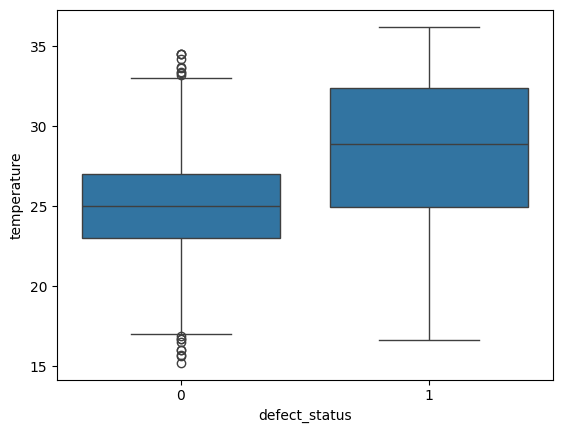

In [ ]:
sns.boxplot(data=defect_df, x='defect_status', y='temperature')

In [ ]:
답안03 = '0'

4.

In [ ]:
print(pd.crosstab(defect_df['production_line'], defect_df['defect_status'], normalize='index'))

defect_status           0         1
production_line                    
Line-1           1.000000  0.000000
Line-2           1.000000  0.000000
Line-3           0.990239  0.009761


5.

In [ ]:
defect_df.groupby(['shift'])[['measurement_A', 'measurement_B', 'measurement_C']].mean()

,measurement_A,measurement_B,measurement_C
shift,,,
야간,100.122778,199.168808,50.070927
주간,100.395550,199.286604,50.189282


6.

In [ ]:
defect_pre = defect_df.copy()

defect_pre['operator_experience_years'].fillna(defect_pre['operator_experience_years'].median(), inplace=True)

defect_pre['processing_time_min'].fillna(defect_pre['processing_time_min'].mean(), inplace=True)

/tmp/ipykernel_1901/594859762.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  defect_pre['operator_experience_years'].fillna(defect_pre['operator_experience_years'].median(), inplace=True)
/tmp/ipykernel_1901/594859762.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

7.

In [ ]:
defect_pre['shift'] = defect_pre['shift'].map({'주간':0, '야간':1})

defect_pre = pd.get_dummies(data=defect_pre, columns=['production_line'])

8.

In [ ]:
defect_pre['measurement_ratio'] = defect_pre['measurement_A'] / defect_pre['measurement_B']

X = defect_pre.drop(columns=['defect_status'])
y = defect_pre['defect_status']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=2024, stratify=y)

9.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

10.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=5, random_state=2024)

model_dt.fit(X_train_scaled, y_train)

dt_pred = model_dt.predict(X_valid_scaled)

11.

In [ ]:
model_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=2024)

model_gb.fit(X_train_scaled, y_train)

gb_ored = model_gb.predict(X_valid_scaled)

12.

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

print('DecisionTreeClassifier')
print('ACC : ', accuracy_score(y_valid, dt_pred))
print('ROC_AUC : ', roc_auc_score(y_valid, model_dt.predict_proba(X_valid_scaled)[:,1]))

print('GradientBoostingClassifier')
print('ACC : ', accuracy_score(y_valid, gb_ored))
print('ROC_AUC : ', roc_auc_score(y_valid, model_gb.predict_proba(X_valid_scaled)[:,1]))

DecisionTreeClassifier
ACC :  0.995
ROC_AUC :  0.5050167224080268
GradientBoostingClassifier
ACC :  0.9966666666666667
ROC_AUC :  0.9648829431438127


13.

In [ ]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train, epochs=25, batch_size=32, validation_data=(X_valid_scaled, y_valid))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8908 - loss: 0.3460 - val_accuracy: 0.9967 - val_loss: 0.1100
Epoch 2/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9967 - loss: 0.0758 - val_accuracy: 0.9967 - val_loss: 0.0376
Epoch 3/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9971 - loss: 0.0344 - val_accuracy: 0.9967 - val_loss: 0.0285
Epoch 4/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9971 - loss: 0.0251 - val_accuracy: 0.9967 - val_loss: 0.0265
Epoch 5/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9971 - loss: 0.0214 - val_accuracy: 0.9967 - val_loss: 0.0258
Epoch 6/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9971 - loss: 0.0214 - val_accuracy: 0.9967 - val_loss: 0.0251
Epoch 7/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9971 - loss: 0.0198 - val_accuracy: 0.9967 - val_loss: 0.0246
Epoch 8/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9971 - loss: 0.0190 - val_accuracy: 0.9967 - val_loss

14.

In [ ]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_product_data = np.array([[1, 10.0, 25.0, 28.0, 55.0, 105.0, 195.0, 50.0, 0.538, 0, 1, 0]])

In [ ]:
new_product_data_scaled = scaler.transform(new_product_data)

predicted_defect_prob = model.predict(new_product_data_scaled)
print(f"새로운 제품의 예측 불량 여부: {predicted_defect_prob[0][0]:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
새로운 제품의 예측 불량 여부: 0.0000
